In [1]:
import polars as pl
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from procompa import get_project_root

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

In [2]:
one_model = pl.read_parquet(data_dir / "Pipeline/10_all_CP_complexes/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")

#add confidence
conf_om = {}
for d in {Path(p).parent for p in one_model["combfold_output_path"]}:
    conf_om .update(dict(line.split() for line in open(d / "confidence.txt")))

one_model = one_model.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf_om[p]), return_dtype=pl.Float64).alias("CF_confidence"))
#filter_bigger_proteins
one_model= one_model.filter(pl.col("n_proteins") > 2)
one_model_one_per_complex = one_model.sort("CF_confidence", descending=True).group_by("complex_ac").first()

multiple_input_models = pl.read_parquet(data_dir / "Pipeline/14_CF_multiple_models/cf_pdb_structure_similarity/cf_pdb_eval_all_metrics.parquet")

conf_mm = {}
for d in {Path(p).parent for p in multiple_input_models["combfold_output_path"]}:
    conf_mm .update(dict(line.split() for line in open(d / "confidence.txt")))

multiple_input_models = multiple_input_models.with_columns(pl.col("combfold_output_path").map_elements(lambda p: float(conf_mm[p]), return_dtype=pl.Float64).alias("CF_confidence"))
multiple_input_models = multiple_input_models.filter(pl.col("n_proteins") > 2)
multiple_input_models_one_per_complex  = multiple_input_models.sort("CF_confidence", descending=True).group_by("complex_ac").first()

In [5]:
a = set(one_model_one_per_complex["complex_ac"])
b = set(multiple_input_models_one_per_complex["complex_ac"])

print(f"1-model: {len(a)}   5-model: {len(b)}   shared: {len(a & b)}")
print(f"only in 1-model: {sorted(a - b)}")
print(f"only in 5-model: {sorted(b - a)}")

1-model: 41   5-model: 43   shared: 41
only in 1-model: []
only in 5-model: ['CPX-1040', 'CPX-2156']


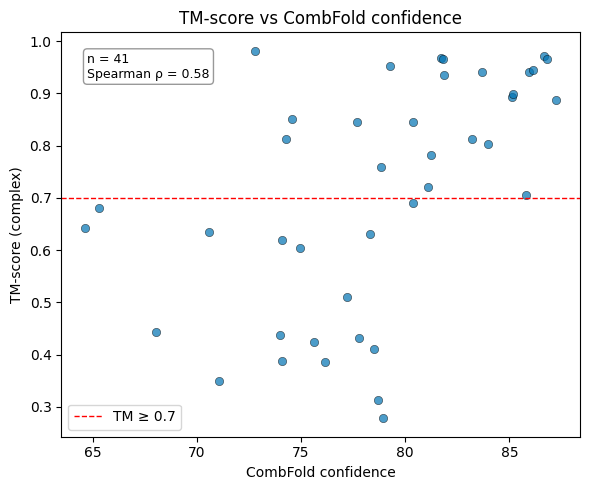

In [5]:

#sanity check
one_model_one_per_complex = one_model.sort("CF_confidence", descending=True).group_by("complex_ac").first()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    one_model_one_per_complex["CF_confidence"], one_model_one_per_complex["usalign_cpx_tm_score"],
    alpha=0.7, edgecolors="k", linewidths=0.4, color="#0072B2"
)
ax.axhline(0.7, color="red", linestyle="--", linewidth=1, label="TM ≥ 0.7")
ax.set_xlabel("CombFold confidence")
ax.set_ylabel("TM-score (complex)")
ax.set_title("TM-score vs CombFold confidence")
ax.legend()

x = one_model_one_per_complex["CF_confidence"].to_numpy()
y = one_model_one_per_complex["usalign_cpx_tm_score"].to_numpy()
spearman_r, spearman_p = stats.spearmanr(x, y)

ax.annotate(
    f"n = {len(x)}\nSpearman ρ = {spearman_r:.2f}",
    xy=(0.05, 0.95), xycoords="axes fraction", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8)
)
fig.tight_layout()
plt.show()


In [6]:
eval_comparison = (
    one_model_one_per_complex.select("complex_ac", usalign_cpx_tm_score_1model="usalign_cpx_tm_score")
    .join(
        multiple_input_models_one_per_complex.select("complex_ac", usalign_cpx_tm_score_5models="usalign_cpx_tm_score"),
        on="complex_ac",
        how="inner",
    )
)

In [7]:
eval_comparison = (
    one_model_one_per_complex.select(
        "complex_ac",
        usalign_cpx_tm_score_1model="usalign_cpx_tm_score",
        CF_confidence_1model="CF_confidence",
    )
    .join(
        multiple_input_models_one_per_complex.select(
            "complex_ac",
            usalign_cpx_tm_score_5models="usalign_cpx_tm_score",
            CF_confidence_5models="CF_confidence",
        ),
        on="complex_ac",
        how="inner",
    )
    .with_columns(
        (pl.col("usalign_cpx_tm_score_5models") - pl.col("usalign_cpx_tm_score_1model")).alias("delta_tm"),
        (pl.col("CF_confidence_5models") - pl.col("CF_confidence_1model")).alias("delta_conf"),
    )
    .with_columns(
        pl.when(pl.col("delta_tm") > 0.01).then(pl.lit("5models better"))
        .when(pl.col("delta_tm") < -0.01).then(pl.lit("1model better"))
        .otherwise(pl.lit("tied"))
        .alias("winner_tm"),
        pl.when(pl.col("delta_conf") > 0.01).then(pl.lit("5models better"))
        .when(pl.col("delta_conf") < -0.01).then(pl.lit("1model better"))
        .otherwise(pl.lit("tied"))
        .alias("winner_conf"),
    )
    .sort("delta_tm")
)

In [8]:
eval_comparison

shape: (41, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ complex_a ┆ usalign_c ┆ CF_confid ┆ usalign_c ┆ … ┆ delta_tm ┆ delta_con ┆ winner_tm ┆ winner_co │
│ c         ┆ px_tm_sco ┆ ence_1mod ┆ px_tm_sco ┆   ┆ ---      ┆ f         ┆ ---       ┆ nf        │
│ ---       ┆ re_1model ┆ el        ┆ re_5model ┆   ┆ f64      ┆ ---       ┆ str       ┆ ---       │
│ str       ┆ ---       ┆ ---       ┆ s         ┆   ┆          ┆ f64       ┆           ┆ str       │
│           ┆ f64       ┆ f64       ┆ ---       ┆   ┆          ┆           ┆           ┆           │
│           ┆           ┆           ┆ f64       ┆   ┆          ┆           ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ CPX-1810  ┆ 0.6812    ┆ 65.2956   ┆ 0.37447   ┆ … ┆ -0.30673 ┆ 7.4191    ┆ 1model    ┆ 5models   │
│           ┆           ┆           ┆           ┆   ┆          ┆           ┆